In [15]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import joblib
import random
import numpy as np
from scipy.stats import linregress
import torch
from matplotlib import pyplot as plt
import matplotlib as mpl
from syd import make_viewer, Viewer
from tqdm import tqdm
from rastermap import Rastermap
import optuna

from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer, sort_by_preferred_environment, edge2center, beeswarm, format_spines, insert_nans_at_gaps, cross_validate_trials, save_figure
from vrAnalysis.sessions import B2Session, SpksTypes
from vrAnalysis.processors import SpkmapProcessor
from vrAnalysis.processors.support import median_zscore
from vrAnalysis.processors.placefields import get_placefield, get_frame_behavior, get_placefield_prediction
from dimilibi.pca import PCA
from dimilibi.cvpca import RegularizedCVPCA, CVPCA
from dimilibi import gaussian_filter, fit_powerlaw_decay
from dimensionality_manuscript.registry import PopulationRegistry, get_model, ModelName, short_model_name
from dimensionality_manuscript.workflows.test_em import get_filepath as get_em_filepath, ExpMaxConfig


plt.rcParams["font.size"] = 18

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
registry = PopulationRegistry()
cfg = ExpMaxConfig()

In [19]:
# Evaluate whether RRR internals contain the information in the RBFPos internals
spks_type = "oasis"

mouse_names = []
session_iterable = sessiondb.iter_sessions(imaging=True, session_params=dict(spks_type=spks_type))
num_sessions = len(session_iterable)

REQUIRED_KEYS = [
    "em_test_r2",
    "em_null_r2",
    "em_test_rms",
    "em_null_rms",
    "em_test_mse",
    "em_null_mse",
    "step_mse",
    "step_r2",
    "step_rms",
]

em_test_r2 = np.full((len(session_iterable),), np.nan)
em_null_r2 = np.full((len(session_iterable),), np.nan)
em_test_rms = np.full((len(session_iterable),), np.nan)
em_null_rms = np.full((len(session_iterable),), np.nan)
em_test_mse = np.full((len(session_iterable),), np.nan)
em_null_mse = np.full((len(session_iterable),), np.nan)
step_mse = np.full((len(session_iterable), cfg.num_steps), np.nan)
step_r2 = np.full((len(session_iterable), cfg.num_steps), np.nan)
step_rms = np.full((len(session_iterable), cfg.num_steps), np.nan)


for isession, session in enumerate(tqdm(session_iterable)):
    mouse_names.append(session.mouse_name)
    results_fpath = get_em_filepath(session, cfg)
    if results_fpath.exists():
        results = joblib.load(results_fpath)
    else:
        continue

    em_test_r2[isession] = results["em_test_r2"]
    em_null_r2[isession] = results["em_null_r2"]
    em_test_rms[isession] = results["em_test_rms"]
    em_null_rms[isession] = results["em_null_rms"]
    em_test_mse[isession] = results["em_test_mse"]
    em_null_mse[isession] = results["em_null_mse"]
    step_mse[isession] = results["step_mse"]
    step_r2[isession] = results["step_r2"]
    step_rms[isession] = results["step_rms"]
    session.clear_cache()

mice = list(set(mouse_names))
mouse_names = np.array(mouse_names)
avg_em_test_r2 = np.full((len(mice),), np.nan)
avg_em_null_r2 = np.full((len(mice),), np.nan)
avg_em_test_rms = np.full((len(mice),), np.nan)
avg_em_null_rms = np.full((len(mice),), np.nan)
avg_em_test_mse = np.full((len(mice),), np.nan)
avg_em_null_mse = np.full((len(mice),), np.nan)
avg_step_mse = np.full((len(mice), cfg.num_steps), np.nan)
avg_step_r2 = np.full((len(mice), cfg.num_steps), np.nan)
avg_step_rms = np.full((len(mice), cfg.num_steps), np.nan)
for imouse, mouse in enumerate(mice):
    if np.sum(mouse_names == mouse) == 0:
        print(f"No sessions for {mouse}")
        continue

    idx_mouse = np.where(mouse_names == mouse)[0]
    num_nan_sessions = np.sum(np.isnan(em_test_r2[idx_mouse]))
    if num_nan_sessions > 0:
        print(f"Warning: {num_nan_sessions}/{len(idx_mouse)} sessions for {mouse} are missing EM results and will be skipped in averages.")
    avg_em_test_r2[imouse] = np.nanmean(em_test_r2[idx_mouse])
    avg_em_null_r2[imouse] = np.nanmean(em_null_r2[idx_mouse])
    avg_em_test_rms[imouse] = np.nanmean(em_test_rms[idx_mouse])
    avg_em_null_rms[imouse] = np.nanmean(em_null_rms[idx_mouse])
    avg_em_test_mse[imouse] = np.nanmean(em_test_mse[idx_mouse])
    avg_em_null_mse[imouse] = np.nanmean(em_null_mse[idx_mouse])
    avg_step_mse[imouse] = np.nanmean(step_mse[idx_mouse], axis=0)
    avg_step_r2[imouse] = np.nanmean(step_r2[idx_mouse], axis=0)
    avg_step_rms[imouse] = np.nanmean(step_rms[idx_mouse], axis=0)

100%|██████████| 149/149 [00:00<00:00, 17401.81it/s]


C:\Users\Andrew\AppData\Local\Temp\ipykernel_886852\1357612334.py:70: RuntimeWarning: Mean of empty slice
  avg_em_test_r2[imouse] = np.nanmean(em_test_r2[idx_mouse])
C:\Users\Andrew\AppData\Local\Temp\ipykernel_886852\1357612334.py:71: RuntimeWarning: Mean of empty slice
  avg_em_null_r2[imouse] = np.nanmean(em_null_r2[idx_mouse])
C:\Users\Andrew\AppData\Local\Temp\ipykernel_886852\1357612334.py:72: RuntimeWarning: Mean of empty slice
  avg_em_test_rms[imouse] = np.nanmean(em_test_rms[idx_mouse])
C:\Users\Andrew\AppData\Local\Temp\ipykernel_886852\1357612334.py:73: RuntimeWarning: Mean of empty slice
  avg_em_null_rms[imouse] = np.nanmean(em_null_rms[idx_mouse])
C:\Users\Andrew\AppData\Local\Temp\ipykernel_886852\1357612334.py:74: RuntimeWarning: Mean of empty slice
  avg_em_test_mse[imouse] = np.nanmean(em_test_mse[idx_mouse])
C:\Users\Andrew\AppData\Local\Temp\ipykernel_886852\1357612334.py:75: RuntimeWarning: Mean of empty slice
  avg_em_null_mse[imouse] = np.nanmean(em_null_mse[i

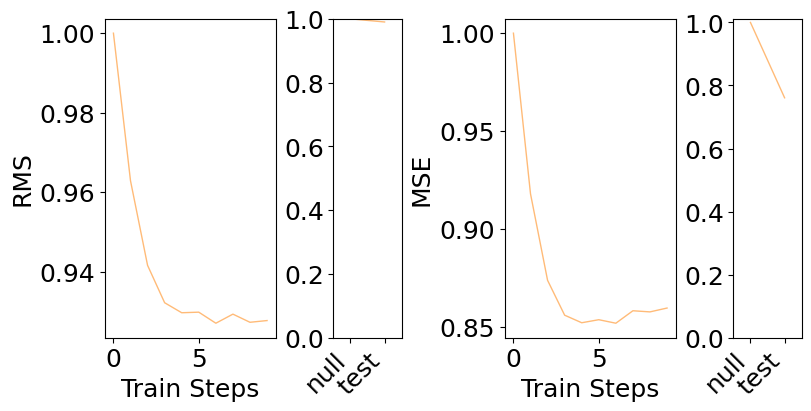

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(8, 4), width_ratios=[1, 0.4, 1, 0.4], layout="constrained")

metrics = [
    ("RMS", avg_em_test_rms, avg_em_null_rms, avg_step_rms, 1e2),
    ("MSE", avg_em_test_mse, avg_em_null_mse, avg_step_mse, 1e3),
]

beeswarm_scale = 0.5
step_positions = np.arange(cfg.num_steps)

mouse_colors = mpl.colormaps["tab20"].colors[: len(mice)]

for iax_group, (label, test, null, steps, scale) in enumerate(metrics):
    ax_train = axes[iax_group * 2]
    ax_test = axes[iax_group * 2 + 1]
    for imouse in range(len(mice)):
        ax_test.plot([0, 1], [null[imouse] / null[imouse], test[imouse] / null[imouse]], color=mouse_colors[imouse], linewidth=1)
        ax_train.plot(step_positions, steps[imouse] / steps[imouse][0], color=mouse_colors[imouse], linewidth=1)
    ax_test.set_xticks([0, 1])
    ax_test.set_xlim(-0.5, 1.5)
    ax_test.set_xticklabels(["null", "test"], rotation=45, ha="right")
    ax_train.set_ylabel(label)
    ax_train.set_xlim(-0.5, cfg.num_steps - 0.5)
    ax_train.set_xlabel("Train Steps")
    # ax_train.set_ylim(0)
    ax_test.set_ylim(0)

plt.show()